# Hierarchical Risk Parity

HRP is a modern portfolio optimization method inspired by machine learning.

The idea is that by examining the hierarchical structure of the market, we can better diversify. 

In this cookbook recipe, we will cover:

- Downloading data for HRP
- Using HRP to find the minimum variance portfolio
- Plotting dendrograms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/5-Hierarchical-Risk-Parity.ipynb)
    
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/PyPortfolio/PyPortfolioOpt/blob/main/cookbook/5-Hierarchical-Risk-Parity.ipynb)
    
[![Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/5-Hierarchical-Risk-Parity.ipynb)
    
[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/pyportfolio/pyportfolioopt/blob/master/cookbook/5-Hierarchical-Risk-Parity.ipynb)


## Downloading data

HRP only requires historical returns

In [10]:
!pip install pandas numpy matplotlib PyPortfolioOpt
import os
if not os.path.isdir('data'):
    os.system('git clone https://github.com/pyportfolio/pyportfolioopt.git')
    os.chdir('PyPortfolioOpt/cookbook')


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import pypfopt
from pypfopt.data.data_loader import load_stockdata

pypfopt.__version__

'1.6.0'

In [12]:
tickers = ["BLK", "BAC", "AAPL", "TM", "WMT",
           "JD", "INTU", "MA", "UL", "CVS",
           "DIS", "AMD", "NVDA", "PBI", "TGT"]

prices = load_stockdata(tickers=tickers)
prices

,BLK,BAC,AAPL,TM,WMT,JD,INTU,MA,UL,CVS,DIS,AMD,NVDA,PBI,TGT
date,,,,,,,,,,,,,,,
2021-01-01,99.678920,243.061192,85.231056,190.319299,156.885255,78.967265,139.616432,65.889588,173.448899,253.865357,226.714336,68.637661,209.389368,271.803186,240.196262
2021-01-04,97.031552,241.727036,82.691515,189.923327,159.801401,79.315505,140.308696,66.869000,166.613668,256.071502,226.031949,69.886845,208.376632,257.042918,241.719643
2021-01-05,95.891954,240.661725,79.791371,190.005155,160.947747,80.149243,140.342242,65.728726,168.781889,257.543183,225.185988,68.558348,205.306042,257.483402,244.642931
2021-01-06,96.869824,239.795313,80.867784,187.004685,162.955586,81.451779,136.842043,67.496486,173.097473,259.161933,230.128279,68.057855,201.129055,263.262290,242.210868
2021-01-07,99.019639,239.231142,81.130220,187.681523,164.842627,81.513278,139.294123,66.849581,176.780048,267.194540,230.539394,67.054195,198.012522,260.457168,248.111604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-20,236.957811,387.472514,73.227495,201.199378,153.952289,107.773849,29.576250,28.650668,93.906929,543.967296,376.332974,76.977638,168.277816,811.267098,158.874208
2023-11-21,237.618544,384.432159,72.594342,201.984769,153.962735,108.929653,30.303914,29.173991,93.998433,537.480002,369.415006,74.658651,166.003208,805.701067,159.605292
2023-11-22,234.597076,387.754766,72.448156,204.429219,153.434877,107.750260,29.483114,29.005877,90.595175,535.082155,363.789606,73.224889,163.351990,768.336524,158.053646


In [13]:
from pypfopt import expected_returns

rets = expected_returns.returns_from_prices(prices)
rets.tail()

,BLK,BAC,AAPL,TM,WMT,JD,INTU,MA,UL,CVS,DIS,AMD,NVDA,PBI,TGT
date,,,,,,,,,,,,,,,
2023-11-20,0.017760,0.009193,0.008098,-0.021412,0.003140,0.004429,0.008234,-0.036671,0.004683,-0.016386,-0.015543,0.002896,-0.005415,-0.000531,0.009905
2023-11-21,0.002788,-0.007847,-0.008646,0.003904,0.000068,0.010724,0.024603,0.018266,0.000974,-0.011926,-0.018383,-0.030125,-0.013517,-0.006861,0.004602
2023-11-22,-0.012716,0.008643,-0.002014,0.012102,-0.003428,-0.010827,-0.027086,-0.005762,-0.036205,-0.004461,-0.015228,-0.019204,-0.015971,-0.046375,-0.009722
2023-11-23,-0.003206,0.010966,-0.013902,0.005247,0.005818,-0.007838,-0.001358,-0.005528,0.017006,0.003383,-0.019269,0.004538,0.012588,-0.020318,0.005442
2023-11-24,-0.002963,0.018719,-0.013723,0.034517,0.008925,-0.010026,0.009094,-0.009083,0.013423,-0.013415,0.003070,0.011080,0.017671,-0.042103,-0.009964


## HRP optimization

HRP uses a completely different backend, so it is currently not possible to pass constraints or specify an objective function.

In [14]:
from pypfopt import HRPOpt

In [15]:
hrp = HRPOpt(rets)
hrp.optimize()
weights = hrp.clean_weights()
weights

OrderedDict([('BLK', 0.05462),
             ('BAC', 0.13642),
             ('AAPL', 0.03071),
             ('TM', 0.06986),
             ('WMT', 0.08478),
             ('JD', 0.08316),
             ('INTU', 0.04527),
             ('MA', 0.02827),
             ('UL', 0.03587),
             ('CVS', 0.1418),
             ('DIS', 0.04977),
             ('AMD', 0.03914),
             ('NVDA', 0.06482),
             ('PBI', 0.04034),
             ('TGT', 0.09517)])

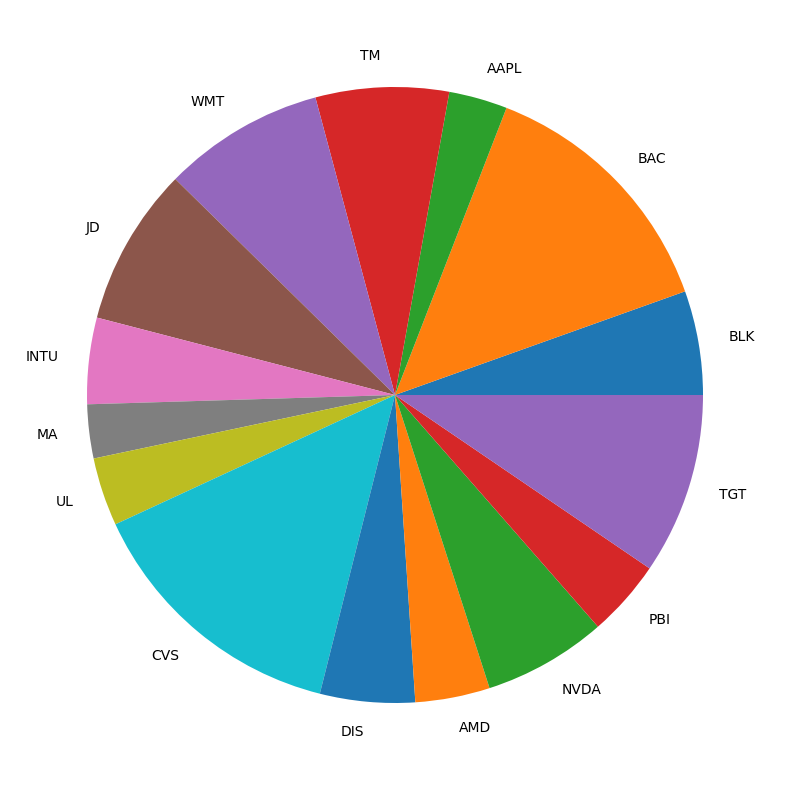

In [16]:
pd.Series(weights).plot.pie(figsize=(10, 10));

In [17]:
hrp.portfolio_performance(verbose=True);

Expected annual return: 7.5%
Annual volatility: 6.2%
Sharpe Ratio: 1.21


## Plotting

It is very simple to plot a dendrogram (tree diagram) based on the hierarchical structure of asset returns

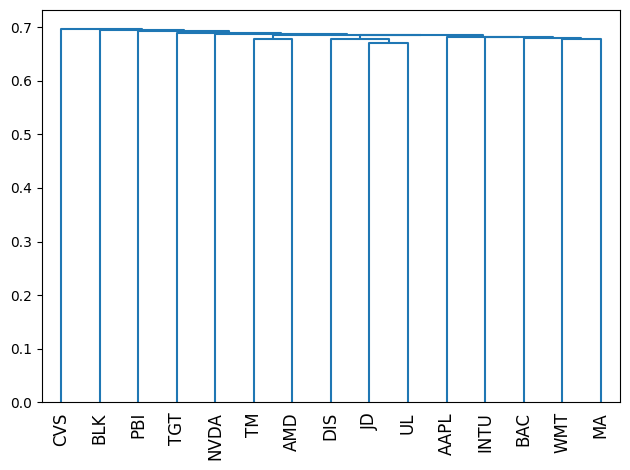

In [18]:
from pypfopt import plotting

plotting.plot_dendrogram(hrp); 

If you look at this dendogram closely, you can see that most of the clusters make a lot of sense. For example, AMD and NVDA (both semiconductor manufacturers) are grouped.